## Black-Scholes-Merton Model's application to S&P 500 ETF fund

This notebook implements the Black–Scholes model and applies it to the
SPDR S&P 500 ETF (SPY). Market data is retrieved using Yahoo Finance,
volatility is estimated using historical returns, aswell as calcuation of greek variables and option pricing.

The project demonstrates financial engineering concepts including:

- stochastic modeling  
- derivatives pricing  
- volatility estimation  
- numerical root finding

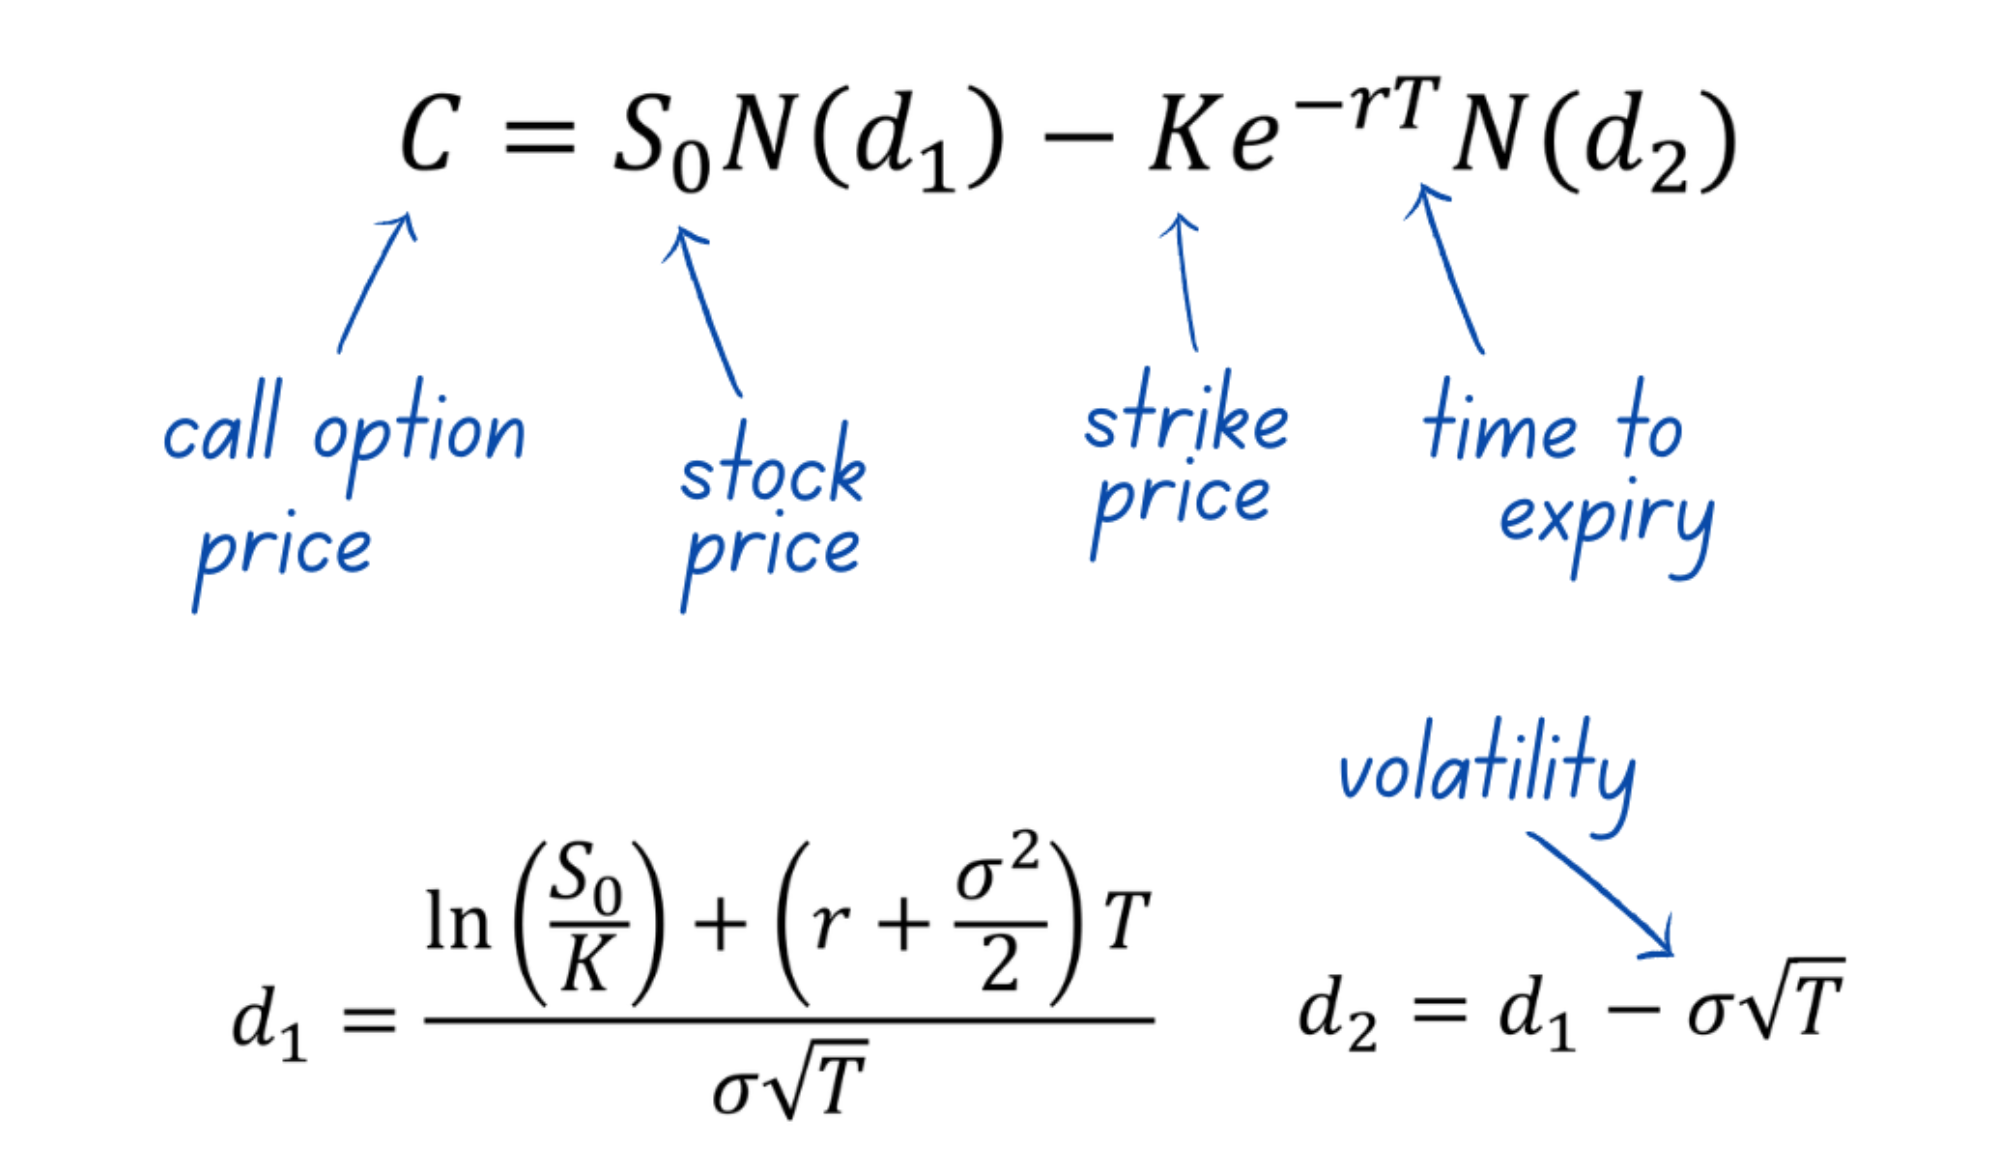

## 1) Import Libraries 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq  
import yfinance as yf
from datetime import datetime

## 2) Retrive Market Data & define variables

In [ ]:
#initialize variables and retrieve risk free interest rate 
s = 664
k = 664
vol = 0.2
t = 1
r = yf.Ticker("^TNX").history(period="1d")["Close"].iloc[-1] / 100

## 3) Black-Scholes Pricing Function 

In [ ]:
def BlackSch(s, k, t, r, vol, option="call"):
    option = option.lower()
#calculating parameters of normal distribution curve.
    d1 = (np.log(s/k) + (r + 0.5 * vol**2)*t) / (vol * np.sqrt(t))
    d2 = d1 -vol*np.sqrt(t)
#call and put calculations.
    if option == "call":
        return s * norm.cdf(d1) - k*np.exp(-r * t) * norm.cdf(d2)
    elif option == "put":
        return k * np.exp(-r * t) * norm.cdf(-d2) - s * norm.cdf(-d1)
    else:
        raise ValueError("option is either 'call' or 'put'")

## 4) Greek & Intermediate Variable Calculation

In [ ]:
def greek(s,k,t,r,vol,):
    d1 = (np.log(s/k) + (r + 0.5* vol**2)* t) / (vol * np.sqrt(t))
    d2 = d1 - vol * np.sqrt(t)
    dt_call = norm.cdf(d1)
    dt_put = dt_call -1
#calculations for risk adjusted measures
    gamma = (norm.pdf(d1) / (s * vol * np.sqrt(t)))
    vega = (s * norm.pdf(d1)* np.sqrt(t)) 

    comp_d1 = (-s * norm.pdf(d1) * vol / (2*np.sqrt(t)))
    comp_d2 = r * k * np.exp(-r * t) * norm.cdf(d2)
    T_call = comp_d1 - comp_d2
    T_put = comp_d1 + comp_d2

    r_call = k * t * np.exp(-r * t) * norm.cdf(d2) 
    r_put = k * t * np.exp(-r * t) * norm.cdf(-d2)
# calculations for all components of Black Scholes Model following GBM
    return {
        "\u0394 Call" : dt_call,
        "\u0394 put" : dt_put,
        "\u0393 gamma" : gamma,
        "V vega" : vega,
        "\u03B8 call" : T_call,
        "\u03B8 put" : T_put,
        "\u03C1 call" : r_call,
        "\u03C1 put" : r_put,
    } 

print("S:", s)
print("K:", k)
print("T:", t)
print("sigma:", vol)
print("r:", r)

## 5) Historical Volatility Estimate of SPY

In [ ]:
def Volatility(price, s, k, t, r, option="call"):
    def objF(vol):
        return BlackSch(s, k, t, r, vol, option) - price
    try:
        Impl_Vol = brentq(objF, 1e-6, 5)
        return Impl_Vol
    except:
        return None
    
#Future volatility and defining the volatility function
            


In [ ]:
ticker = yf.Ticker("SPY")
data = ticker.history(period="1y")
s = data["Close"].iloc[-1]


In [ ]:
returns =np.log(data["Close"] / data["Close"].shift(1))
returns = returns.dropna()
Sig = returns.std()*np.sqrt(252)
print("Calculated Volatility: ", Sig)

#ticker at 3 to eliminate possibility of negative T (option already expired)
expire = ticker.options[3]
options = ticker.option_chain(expire)
calls = options.calls
idx = (calls["strike"] - s).abs().idxmin()
market_price = calls.loc[idx,"lastPrice"]
k = calls.loc[idx, "strike"]
today = datetime.today()
expiry_date = datetime.strptime(expire, "%Y-%m-%d")
t = (expiry_date - today).total_seconds() / (365*12*3600)
if t <= 0:
    print("Option has already expired.")
else:
    Impl_Vol = Volatility(market_price,s,k,t,r)
print("stock price:", s)
print("Strike:", k)
print("Market price:", market_price)
print("Time till expiry:", t)
print("Implied Volatility:", Impl_Vol)



## 6) Option Payoff Visualization 

In [ ]:
def payoff(k):
    s = np.linspace(0, 2 * k, 200)
    p_call = np.maximum(s-k, 0)
    p_put = np.maximum(k-s, 0)
#graphing for the payoff lines
    plt.plot(s, p_call, label = "call payoff")
    plt.plot(s, p_put, label = "put payoff")
    plt.axvline(k, linestyle="--")
    plt.title("Payoff Diagram")
    plt.xlabel("stock/stocks Price")
    plt.ylabel("|profit|")
    plt.legend()
    plt.grid()
    plt.show()


## 7) Option Price as a Function of the Stock Price

In [ ]:
def stock_price(k,t,r,vol):
    S = np.linspace(0.5 * k, 1.5 * k, 200)
    c_price = [BlackSch(s,k,t,r,vol,"call") for s in S]
    p_price = [BlackSch(s,k,t,r,vol,"put") for s in S]
    
#plotting the relation of stocks & option
    plt.plot(S, c_price, label = "Call Price")
    plt.plot(S, p_price, label = "Put Price")
    plt.xlabel("Underlying Price SPY")
    plt.ylabel("Option Price")
    plt.title("Option Price vs Underlying Price (SPY)")
    plt.legend()
    plt.grid()
    plt.show()
    

## 8) Option Price as a Function of Volatility

In [ ]:
vol_range = np.linspace(0.01, 1.5, 200)
prices = []

for v in vol_range:
    prices.append(BlackSch(s, k, t, r, v, "call"))

plt.figure(figsize=(8,5))
plt.plot(vol_range, prices, label="Market Price")
plt.xlabel("Volatility (\N{GREEK SMALL LETTER SIGMA})")
plt.ylabel("Option Price")
plt.title("Black-Scholes Call Price vs Volatility (SPY)")
plt.grid(True)
plt.show()


## 9) Implied Volatility Visualization (BS(σ)=MarketPrice)

In [ ]:
vol_range = np.linspace(0.01, 1.0, 200)
bs_prices = []

for v in vol_range:
    bs_prices.append(BlackSch(s, k, t, r, v, "call"))

plt.figure(figsize=(8,5))
plt.plot(vol_range, bs_prices, label="Black-Scholes Price")
plt.axhline(market_price, color='r', linestyle='--', label="Market Price")
plt.scatter(Impl_Vol, market_price, label="Implied Volatility")
plt.xlabel("Volatility (\N{GREEK SMALL LETTER SIGMA})")
plt.ylabel("Option Price")
plt.title("Implied Volatility Solution")
plt.legend()
plt.grid(True)
plt.show()

## 10) Pricing Example Iteration

In [ ]:
vol = Sig
c_price = BlackSch(s,k,t,r,vol,"call")
print("BS call Price:", c_price)

gs = greek(s,k,t,r,vol)
print("greeks:")
for key, value in gs.items():
    print(key, round(value,4))

MarketPrice = 10
Impl_Vol = Volatility(MarketPrice,s,k,t,r)
print("Implied Volatility:", Impl_Vol)
payoff(k)
stock_price(k,t,r,vol)